### 1. Обрати унікальний датасет з https://archive.ics.uci.edu/datasets, який відповідає наступним вимогам:
* Dataset Characteristics: Multivariate
* Attribute Characteristics: Categorical, Integer, Real
* Number of Attributes: at least 2 integers/real
* Has Missing Values: Yes

**Виконання:**
Обрано Automobile Data Set. Завантажуємо дані з локального файлу.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = [
    'symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
    'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
    'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
    'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
    'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'
]

df = pd.read_csv(url, names=columns)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


### Завдання 2: Здійснити Data Cleaning.

**Виконання:**
У датасеті пропущені значення позначені символом "?". Замінюємо їх на `NaN`, конвертуємо відповідні стовпці у числові формати. Пропуски в числових атрибутах заповнюємо середнім значенням, а в категоріальних (кількість дверей) — найчастішим значенням.

In [4]:
df = df.replace("?", np.nan)

numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

print(f"Кількість пропущених значень після очищення: {df.isna().sum().sum()}")

df.head()

Кількість пропущених значень після очищення: 0


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Завдання 3: Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

**Виконання:**
Побудовано діаграму розсіювання (scatter plot) для візуалізації залежності ціни автомобіля від об'єму його двигуна.

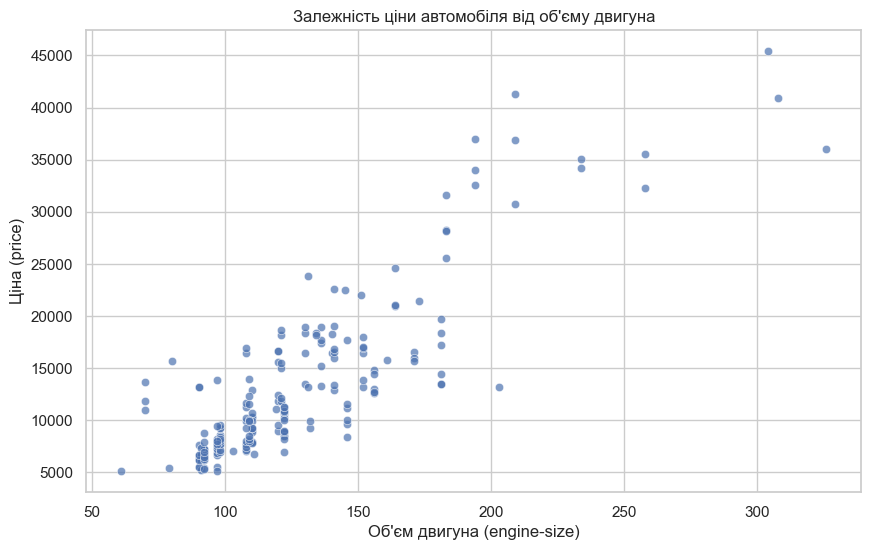

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='engine-size', y='price', alpha=0.7, color='b')
plt.title("Залежність ціни автомобіля від об'єму двигуна")
plt.xlabel("Об'єм двигуна (engine-size)")
plt.ylabel("Ціна (price)")
plt.show()

### Завдання 4: Побудувати гістограму по одному з атрибутів, що буде показувати кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

**Виконання:**
Побудовано гістограму для атрибута `price` (Ціна). Розраховано рівно 5 діапазонів на основі мінімального та максимального значень ціни в датасеті.

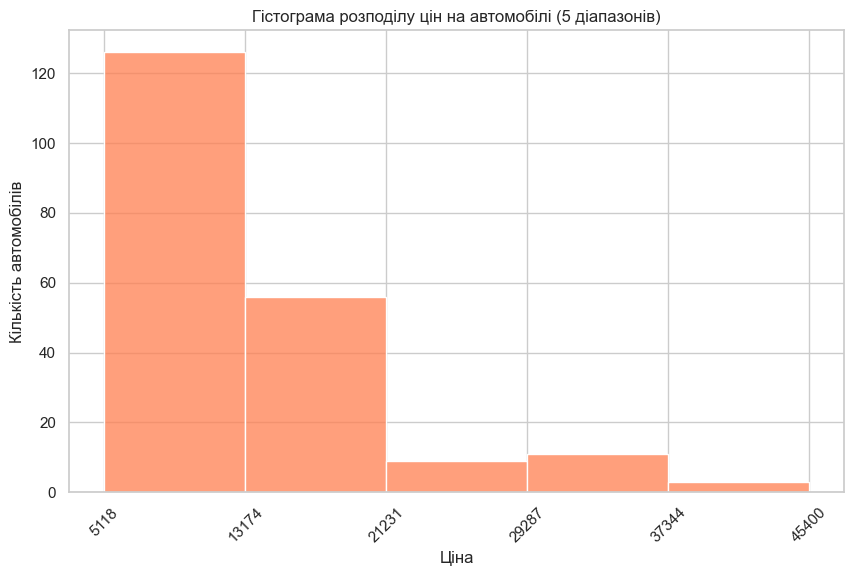

In [6]:
plt.figure(figsize=(10, 6))
bins_custom = np.linspace(df['price'].min(), df['price'].max(), 6) 

sns.histplot(df['price'], bins=bins_custom, kde=False, color='coral')
plt.title("Гістограма розподілу цін на автомобілі (5 діапазонів)")
plt.xlabel("Ціна")
plt.ylabel("Кількість автомобілів")
plt.xticks(bins_custom, rotation=45)
plt.show()

### Завдання 5: Збудувати графіки, використовуючи приклади, наведені y статті: The Art of Effective Visualization of Multi-dimensional Data.

**Виконання:**
Створено багатовимірну візуалізацію (Bubble Chart), яка одночасно відображає 4 виміри: об'єм двигуна (вісь X), ціну (вісь Y), кінські сили (розмір бульбашки) та тип палива (колір).

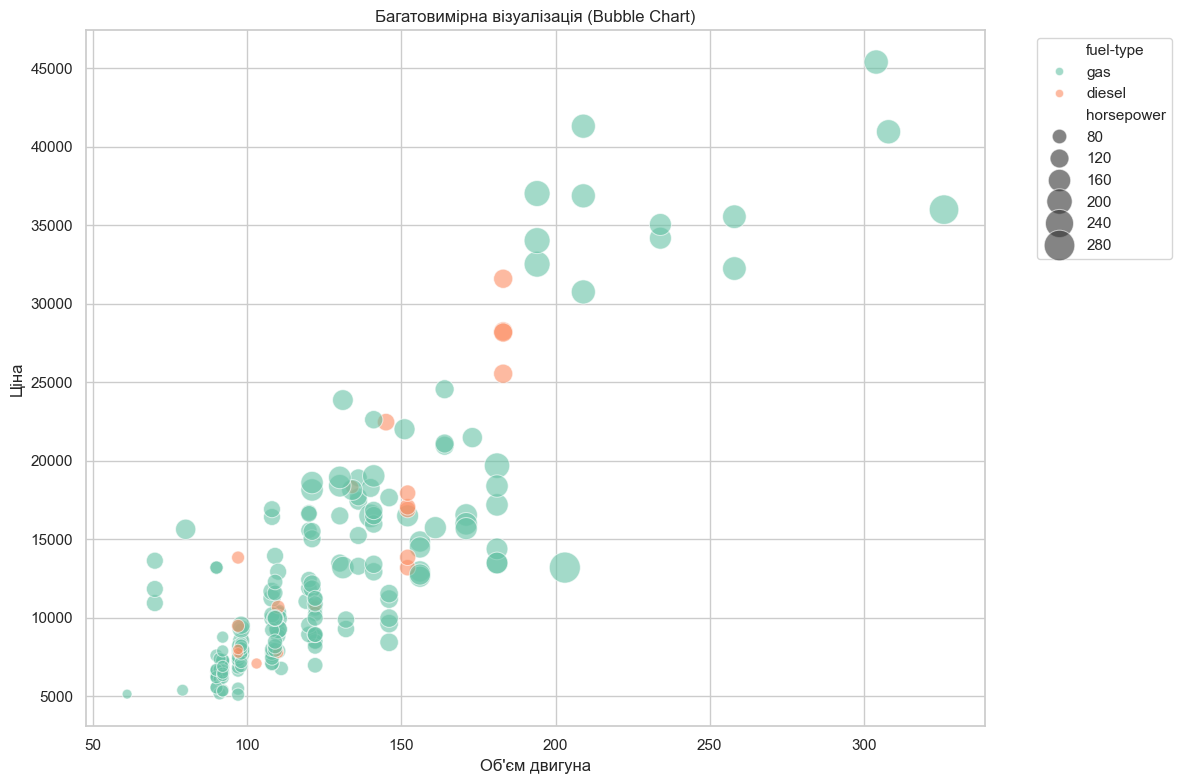

In [7]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='engine-size', 
    y='price', 
    size='horsepower', 
    hue='fuel-type',
    sizes=(50, 500), 
    alpha=0.6, 
    palette='Set2'
)
plt.title("Багатовимірна візуалізація (Bubble Chart)")
plt.xlabel("Об'єм двигуна")
plt.ylabel("Ціна")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Завдання 6: Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.

**Виконання:**
Додано 2 додаткові графіки (загальна кількість у роботі — 5):
1. **Boxplot** для аналізу розподілу цін залежно від типу кузова автомобіля.
2. **Correlation Heatmap** (Теплова карта кореляцій) для відображення сили зв'язку між числовими атрибутами та ціною.

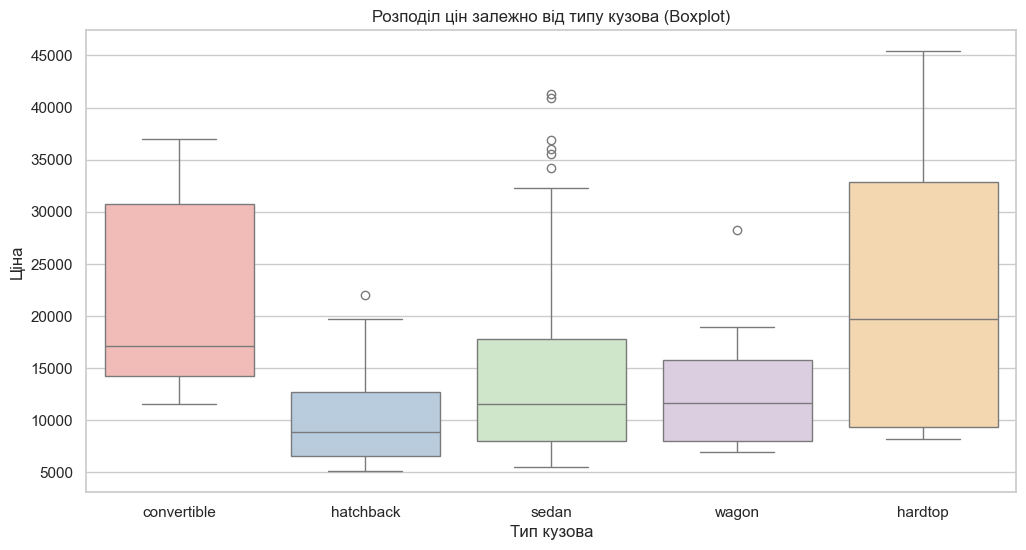

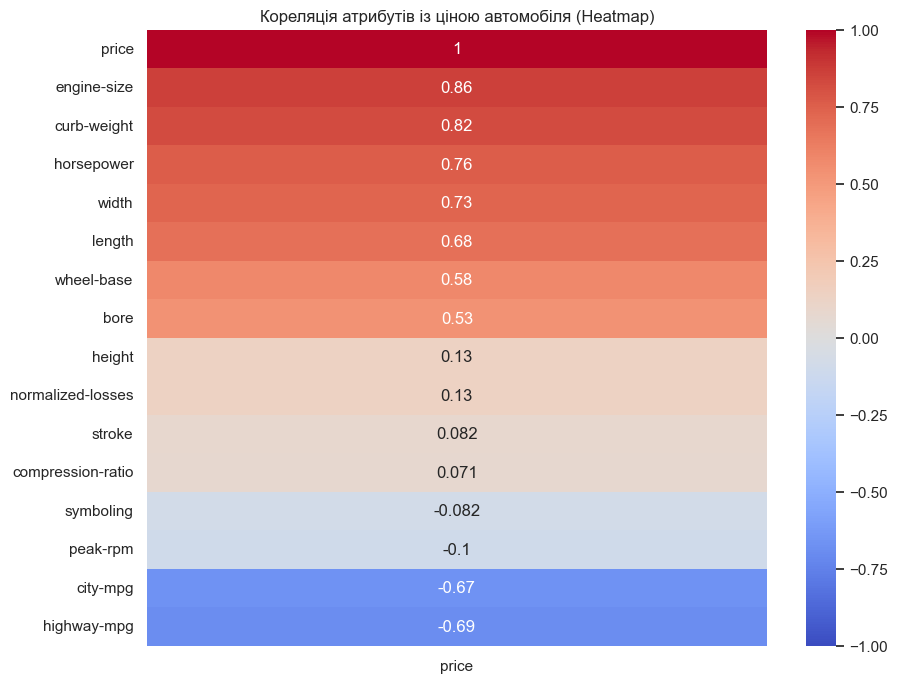

In [9]:
# 1. Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='body-style', y='price', hue='body-style', palette='Pastel1', legend=False)
plt.title("Розподіл цін залежно від типу кузова (Boxplot)")
plt.xlabel("Тип кузова")
plt.ylabel("Ціна")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Кореляція атрибутів із ціною автомобіля (Heatmap)")
plt.show()